# HW2 Policy Gradient — Training Curves

In [1]:
import colorsys
import hashlib
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import wandb

Matplotlib is building the font cache; this may take a moment.


In [2]:
def _base_exp_name(exp_name: str) -> str:
    """Strip the '_lb' size token to get the canonical base name for color lookup."""
    parts = exp_name.split("_")
    return "_".join(p for p in parts if p != "lb")


def expand_cartpole_name(exp_name: str) -> str:
    """Expand abbreviations in an exp_name into a human-readable legend label."""
    parts = exp_name.split("_")
    flag_tokens = [p for p in parts if p not in ("cartpole", "lb")]
    expansions = {"rtg": "reward_to_go=True", "na": "normalize_advantages=T"}
    expanded = [expansions.get(tok, tok) for tok in flag_tokens]
    return ", ".join(expanded) if expanded else "baseline"


def get_exp_color(exp_name: str) -> tuple:
    """Return a deterministic RGB color for *exp_name* via MD5 hash.

    Maps into HSV space using three independent byte ranges so that names
    whose hues collide (inevitable with a 1-D mapping) can still be told
    apart by saturation and brightness:

        bytes 0-3 → hue      (4 B → ~4 billion possible hues)
        byte  4   → sat      0.60 – 0.95  (avoids washed-out pastels)
        byte  5   → val      0.65 – 0.95  (avoids near-black)

    The mapping is stable across calls and independent of which other
    experiments are present, so the same name always gets the same color.
    """
    d = hashlib.md5(exp_name.encode()).digest()
    hue = int.from_bytes(d[0:4], "big") / 2**32   # [0, 1)
    sat = 0.60 + (d[4] / 255.0) * 0.35            # [0.60, 0.95]
    val = 0.65 + (d[5] / 255.0) * 0.30            # [0.65, 0.95]
    return colorsys.hsv_to_rgb(hue, sat, val)


def build_color_map(exp_names: list[str]) -> dict[str, tuple]:
    """
    Assign a consistent tab10 color to each exp name.

    lb variants are collapsed to their base name so that e.g. cartpole and
    cartpole_lb receive the same color.
    """
    palette = plt.cm.tab10.colors
    base_names = list(dict.fromkeys(_base_exp_name(n) for n in exp_names))
    base_colors = {name: palette[i] for i, name in enumerate(base_names)}
    return {name: base_colors[_base_exp_name(name)] for name in exp_names}


def download_runs(
    project: str,
    cache_dir: Path,
    metrics: list[str],
) -> dict[str, dict]:
    """
    Download per-step metrics for every run in *project*.

    Results are cached as JSON under *cache_dir/<run_id>.json* so subsequent
    calls skip already-fetched runs.  The cache is invalidated when a metric
    that appears in the run's summary is missing from the cached DataFrame
    (i.e. a new metric was added after the run was first cached).

    Note: we do NOT pass *metrics* as the ``keys`` argument to
    ``scan_history``, because wandb returns only rows where **all** specified
    keys are present in that row.  Sparse / optional metrics such as
    "Baseline Loss" would therefore drop every row for runs that never log
    them.  Instead we fetch full history and filter to the desired columns.

    Returns a dict keyed by wandb run ID::

        {run_id: {"exp_name": str, "created_at": str, "data": pd.DataFrame}}
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    api = wandb.Api()
    runs = api.runs(project)

    run_data: dict[str, dict] = {}
    for run in runs:
        cache_path = cache_dir / f"{run.id}.json"
        df = None
        if cache_path.exists():
            with open(cache_path) as f:
                df = pd.DataFrame(json.load(f))
            # Invalidate only if a requested metric exists in the run summary
            # but is absent from the cached data — avoids re-fetching just
            # because a run legitimately never logs an optional metric.
            run_summary_keys = set(run.summary.keys())
            needs_refresh = any(
                m in run_summary_keys and m not in df.columns
                for m in metrics
            )
            if needs_refresh:
                cache_path.unlink()
                df = None

        if df is None:
            # Fetch all history (no keys filter) then select the columns we
            # care about.  This avoids the all-keys-required behaviour of
            # scan_history(keys=...).
            rows = list(run.scan_history())
            full_df = pd.DataFrame(rows)
            cols = [c for c in metrics if c in full_df.columns]
            df = full_df[cols] if cols else pd.DataFrame()
            with open(cache_path, "w") as f:
                json.dump(df.to_dict(orient="list"), f)

        run_data[run.id] = {
            "exp_name": run.config.get("exp_name", ""),
            "created_at": run.created_at,
            "data": df,
        }

    return run_data


def group_runs(run_data: dict[str, dict], exp_names: list[str]) -> dict[str, pd.DataFrame]:
    """
    Filter *run_data* to the requested *exp_names*.

    When multiple runs share the same exp_name the most recent one is used and
    a warning is raised.  Returns a dict mapping exp_name → DataFrame.
    """
    groups: dict[str, pd.DataFrame] = {}
    for exp_name in exp_names:
        matches = [
            (rid, info)
            for rid, info in run_data.items()
            if info["exp_name"] == exp_name
        ]
        if not matches:
            warnings.warn(f"No runs found for exp_name '{exp_name}'")
            continue
        if len(matches) > 1:
            warnings.warn(
                f"{len(matches)} runs found for exp_name '{exp_name}' — using the most recent one."
            )
        matches.sort(key=lambda x: x[1]["created_at"], reverse=True)
        groups[exp_name] = matches[0][1]["data"]
    return groups


def make_plot(
    groups: dict[str, pd.DataFrame],
    title: str,
    y_metrics: list[str] | None = None,
    color_map: dict[str, tuple] | None = None,
    save_dir: Path | None = None,
    n_cols: int = 5,
    expand_name = lambda x: x,
) -> None:
    """Plot a grid of subplots, each showing a different metric vs Train_EnvstepsSoFar.

    Default layout is 2 rows × 5 cols: Train metrics on top, Eval metrics on bottom.
    Colors are assigned deterministically per experiment name via ``get_exp_color``
    (hash-based), so the same exp_name always gets the same color regardless of
    which other experiments appear in the plot.  Pass *color_map* to override
    specific names (unmatched names still fall back to ``get_exp_color``).
    If *save_dir* is provided the figure is saved to *save_dir/<title>.png*
    (lowercased, spaces as underscores).
    """
    x_metric = "Train_EnvstepsSoFar"

    # Deterministic color per exp_name; color_map overrides specific entries.
    def _color(name: str) -> tuple:
        if color_map is not None and name in color_map:
            return color_map[name]
        return get_exp_color(name)

    exp_colors = {name: _color(name) for name in groups}

    n_rows = math.ceil(len(y_metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = [ax for row in axes for ax in row]

    for ax, y_metric in zip(axes_flat, y_metrics):
        for exp_name, df in groups.items():
            if df.empty or x_metric not in df.columns or y_metric not in df.columns:
                warnings.warn(f"No plottable data for '{exp_name}' / '{y_metric}'")
                continue
            df_sorted = df.dropna(subset=[x_metric, y_metric]).sort_values(x_metric)
            ax.plot(
                df_sorted[x_metric],
                df_sorted[y_metric],
                label=expand_name(exp_name),
                color=exp_colors[exp_name],
            )
        ax.set_xlabel("Environment Steps")
        ax.set_ylabel(y_metric)
        ax.set_title(y_metric)
        ax.legend(fontsize="small")

    for ax in axes_flat[len(y_metrics):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = title.lower().replace(" ", "_") + ".png"
        fig.savefig(save_dir / filename)

    plt.show()

In [3]:
run_data = download_runs(
    project="cs285_hw2",
    cache_dir=Path("../wandb_cache"),
    metrics=[
        "Train_EnvstepsSoFar",
        "Eval_AverageReturn", "Eval_StdReturn", "Eval_MaxReturn", "Eval_MinReturn", "Eval_AverageEpLen",
        "Train_AverageReturn", "Train_StdReturn", "Train_MaxReturn", "Train_MinReturn", "Train_AverageEpLen",
        "Baseline Loss",
    ],
)

wandb: Currently logged in as: jasonkrone to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [12]:
def make_lunar_lander_plots():
    exp_names = [
        f"discounted_lunar_lander_lambda{l}" for l in [0, 0.95, 0.98, 0.99, 1]
    ]

    print(exp_names)
    runs = group_runs(run_data, exp_names)

    metrics = [
        "Train_AverageReturn", 
        "Eval_AverageReturn", 
        "Train_StdReturn",
        "Eval_StdReturn", 
    ]

    title = "LunarLander_v2"
    save_dir = Path("/Users/jasonkrone/Developer/homework_spring2026/writeup/plots/hw2")

    make_plot(runs, title, y_metrics=metrics, save_dir=save_dir)


['discounted_lunar_lander_lambda0', 'discounted_lunar_lander_lambda0.95', 'discounted_lunar_lander_lambda0.98', 'discounted_lunar_lander_lambda0.99', 'discounted_lunar_lander_lambda1']


/var/folders/s4/lhnl8j753lz0v3hlfvq96fkh0000gn/T/ipykernel_12984/3140036687.py:131: UserWarning: No runs found for exp_name 'discounted_lunar_lander_lambda0.95'
  warnings.warn(f"No runs found for exp_name '{exp_name}'")
/var/folders/s4/lhnl8j753lz0v3hlfvq96fkh0000gn/T/ipykernel_12984/3140036687.py:131: UserWarning: No runs found for exp_name 'discounted_lunar_lander_lambda0.98'
  warnings.warn(f"No runs found for exp_name '{exp_name}'")
/var/folders/s4/lhnl8j753lz0v3hlfvq96fkh0000gn/T/ipykernel_12984/3140036687.py:131: UserWarning: No runs found for exp_name 'discounted_lunar_lander_lambda0.99'
  warnings.warn(f"No runs found for exp_name '{exp_name}'")
/var/folders/s4/lhnl8j753lz0v3hlfvq96fkh0000gn/T/ipykernel_12984/3140036687.py:131: UserWarning: No runs found for exp_name 'discounted_lunar_lander_lambda1'
  warnings.warn(f"No runs found for exp_name '{exp_name}'")


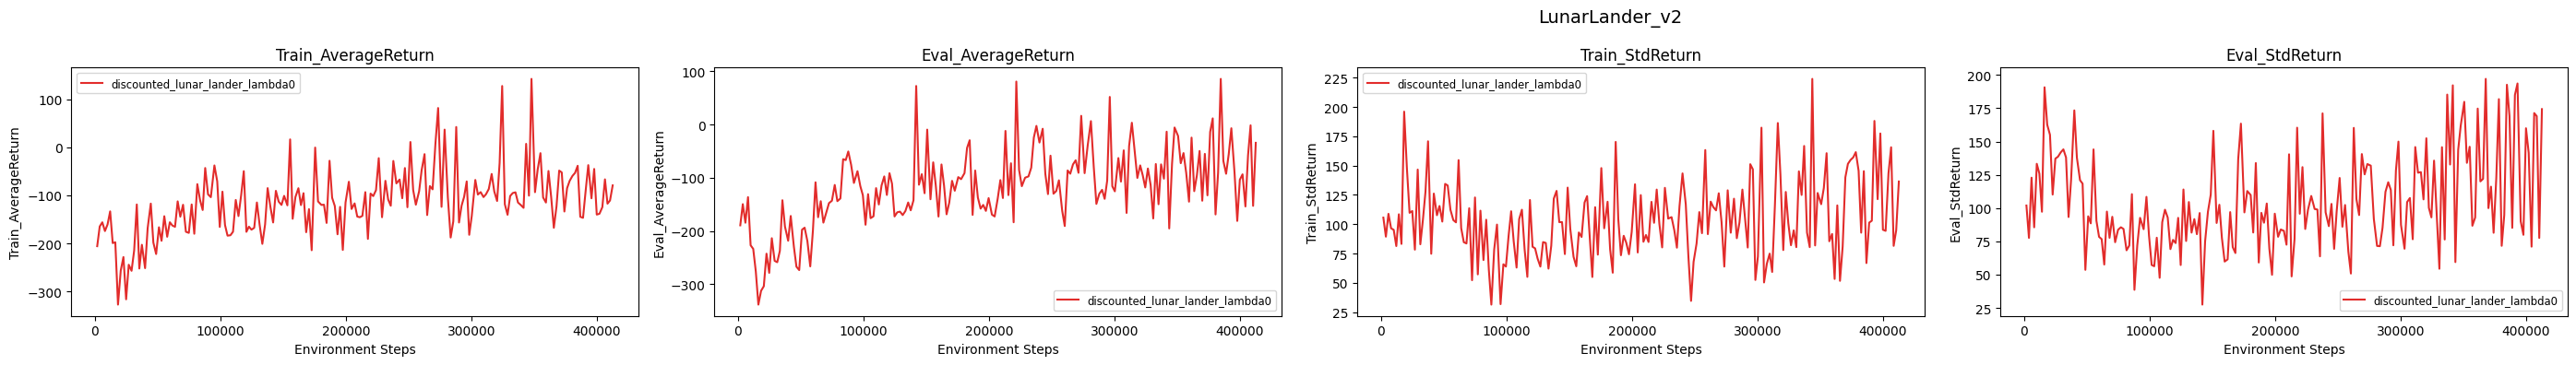

In [13]:
make_lunar_lander_plots()

In [4]:

def make_cartpole_plots():
    exp_dict = {
        "small_batch": ["cartpole", "cartpole_rtg", "cartpole_na", "cartpole_rtg_na"],
        "large_batch": ["cartpole_lb", "cartpole_lb_rtg", "cartpole_lb_na", "cartpole_lb_rtg_na"],
        "rtg": ["cartpole", "cartpole_rtg"],
        "rtg-lb": ["cartpole_lb", "cartpole_lb_rtg"],
        "rtg-na=T": ["cartpole_na", "cartpole_rtg_na"],
        "rtg-lb-na=T": ["cartpole_lb_na", "cartpole_lb_rtg_na"],
    }
    metrics = [
        "Train_AverageReturn", "Train_StdReturn", "Train_MaxReturn", "Train_MinReturn", "Train_AverageEpLen",
        "Eval_AverageReturn", "Eval_StdReturn", "Eval_MaxReturn", "Eval_MinReturn", "Eval_AverageEpLen",
    ]

    color_map = build_color_map(exp_dict["small_batch"] + exp_dict["large_batch"])

    #save_dir = Path("/Users/jasonkrone/Developer/homework_spring2026/writeup/plots/hw2")

    for title, exp_names in exp_dict.items():
        runs = group_runs(run_data, exp_names)
        if "batch" in title:
            make_plot(runs, title, color_map=color_map, y_metrics=metrics, expand_name=expand_cartpole_name)
        else:
            make_plot(runs, title, y_metrics=metrics, expand_name=expand_cartpole_name)

In [ ]:
def make_half_cheetah_plots():
    exp_dict = {
        "half_cheetah_baseline_ablation": ["cheetah", "cheetah_baseline"],
        "half_cheetah_blr_bgs": [
            "cheetah_baseline",  
            'cheetah_baseline_low_blr',
            'cheetah_baseline_low_bgs',
            'cheetah_baseline_low_blr_bgs',
        ],
    }

    metrics = [
        "Baseline Loss",
        "Train_AverageReturn", 
        "Eval_AverageReturn", 
    ]

    save_dir = Path("/Users/jasonkrone/Developer/homework_spring2026/writeup/plots/hw2")

    for title, exp_names in exp_dict.items():
        runs = group_runs(run_data, exp_names)
        make_plot(runs, title, y_metrics=metrics, save_dir=save_dir)


/var/folders/s4/lhnl8j753lz0v3hlfvq96fkh0000gn/T/ipykernel_12984/3140036687.py:178: UserWarning: No plottable data for 'cheetah' / 'Baseline Loss'
  warnings.warn(f"No plottable data for '{exp_name}' / '{y_metric}'")


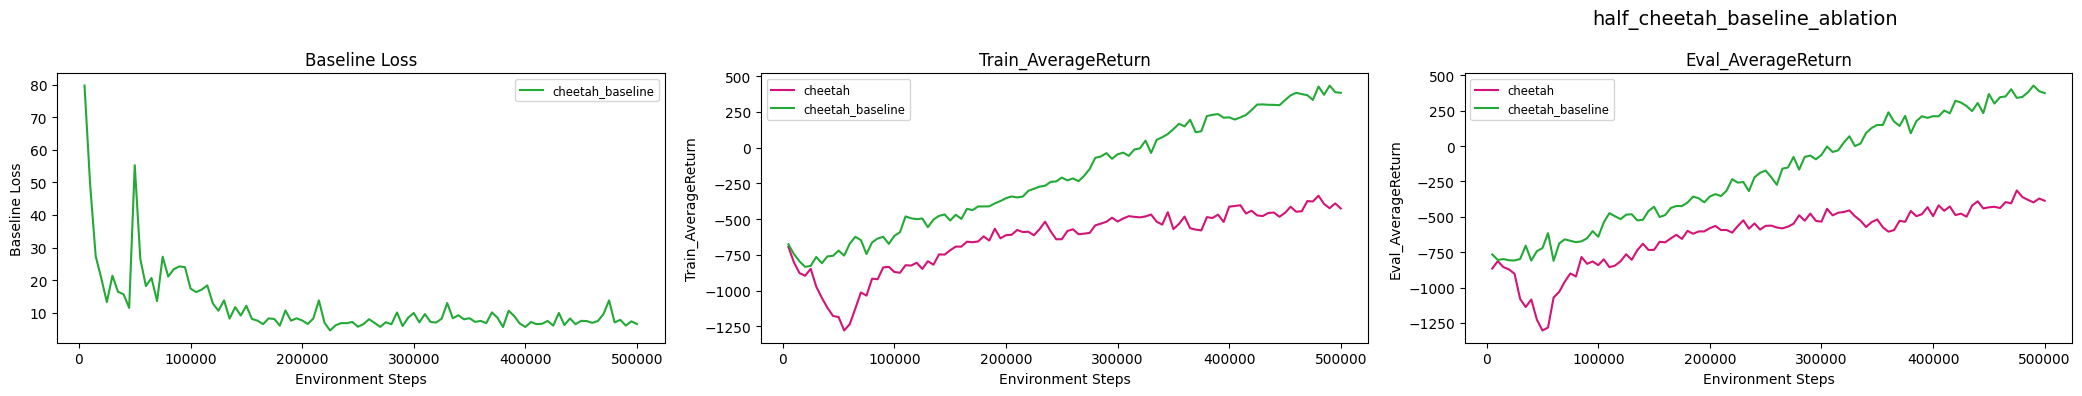

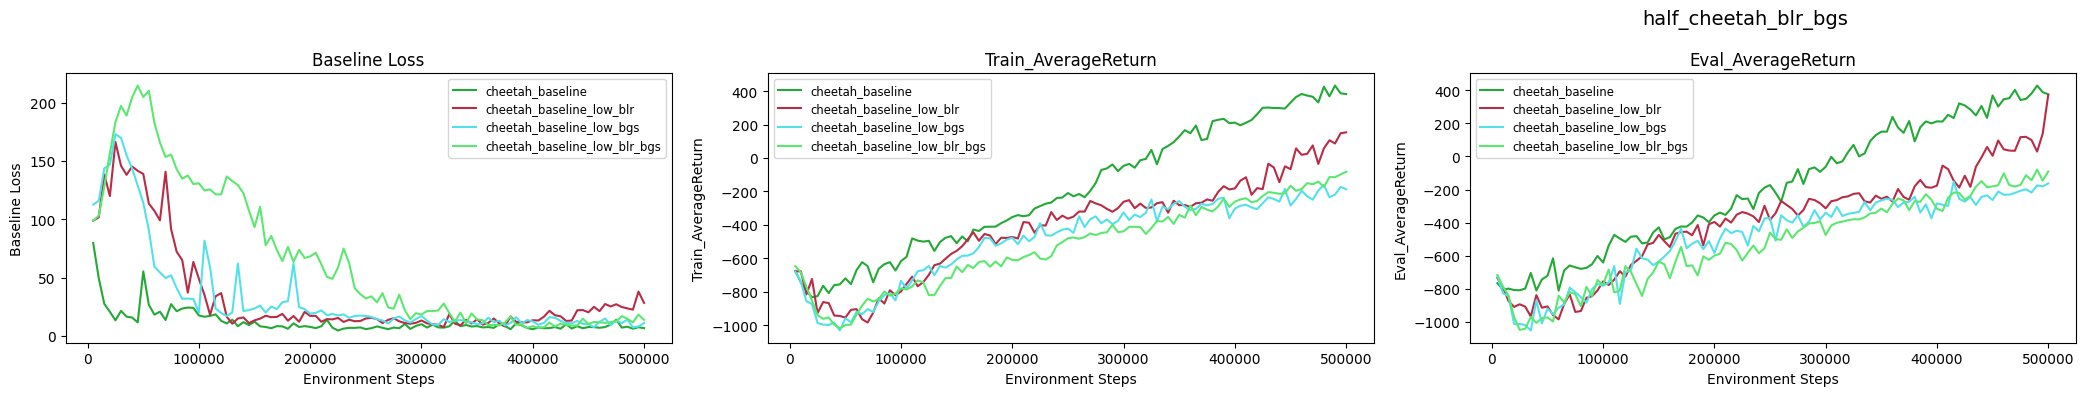

In [6]:
make_half_cheetah_plots()